In [33]:
#Setup & Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = (12, 5)

In [34]:
# Load and filter
df = pd.read_csv('KO_CocaCola_Stock_Prices_1980_2026.csv', parse_dates=['Date'])
df = df[df['Date'] >= '2023-01-01'].reset_index(drop=True)
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
df = df.sort_values('Date').reset_index(drop=True)

print(df.shape)
print(df.isnull().sum())
df.head(20)

(772, 6)
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Date,Open,High,Low,Close,Volume
0,2023-01-03,58.0765,58.0765,56.8156,57.5192,12180500
1,2023-01-04,57.7019,57.8664,57.1171,57.4917,13387900
2,2023-01-05,57.1994,57.3821,56.7242,56.8339,9814700
3,2023-01-06,57.4826,58.1770,57.1811,57.9303,9990000
4,2023-01-09,57.8390,58.2227,57.1811,57.2085,9442600
5,2023-01-10,57.1993,57.3181,56.5780,56.7699,10134600
6,2023-01-11,56.9983,57.1628,56.1120,56.6602,10823000
7,2023-01-12,56.7516,56.8156,55.7100,55.9293,13907300
8,2023-01-13,55.4633,56.1577,55.3628,56.1303,13986400
9,2023-01-17,56.4044,56.9983,56.2491,56.3587,18327800


In [35]:
#Check for gaps in the data
df['gap_days'] = df['Date'].diff().dt.days
print(df['gap_days'].value_counts())

gap_days
1.0    599
3.0    140
4.0     20
2.0     12
Name: count, dtype: int64


In [36]:
# Reindex to a full business-day calendar and interpolate missing values
# This is suitable for stock data because weekends/holidays create gaps in the trading calendar

df = df.set_index('Date').sort_index()
full_index = pd.bdate_range(start=df.index.min(), end=df.index.max(), freq='B')
df = df.reindex(full_index)

for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    df[col] = df[col].interpolate(method='time', limit_direction='both')

df = df.reset_index().rename(columns={'index': 'Date'})

# Isolate the time series data for Volume
ts = df[['Date', 'Volume']].copy()
ts = ts.set_index('Date')
ts.head()

,Volume
Date,
2023-01-03,12180500.0
2023-01-04,13387900.0
2023-01-05,9814700.0
2023-01-06,9990000.0
2023-01-09,9442600.0


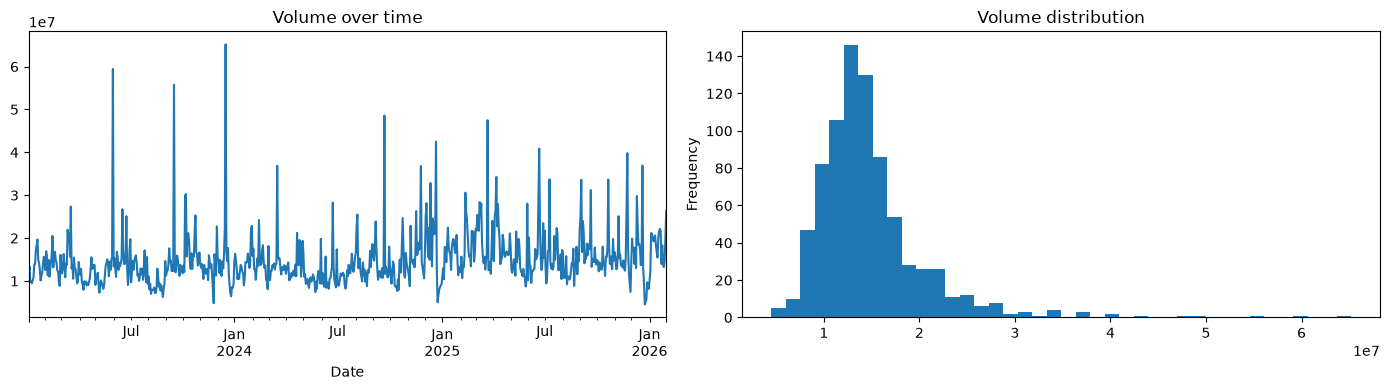

count    8.040000e+02
mean     1.485337e+07
std      6.039674e+06
min      4.515300e+06
25%      1.132435e+07
50%      1.367280e+07
75%      1.633492e+07
max      6.517740e+07
Name: Volume, dtype: float64
Skewness: 2.950038560063593


In [37]:
#Check for distribution and skewness of the data
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ts['Volume'].plot(ax=axes[0], title='Volume over time')
ts['Volume'].plot(kind='hist', bins=40, ax=axes[1], title='Volume distribution')
plt.tight_layout()
plt.show()

print(ts['Volume'].describe())
print('Skewness:', ts['Volume'].skew())

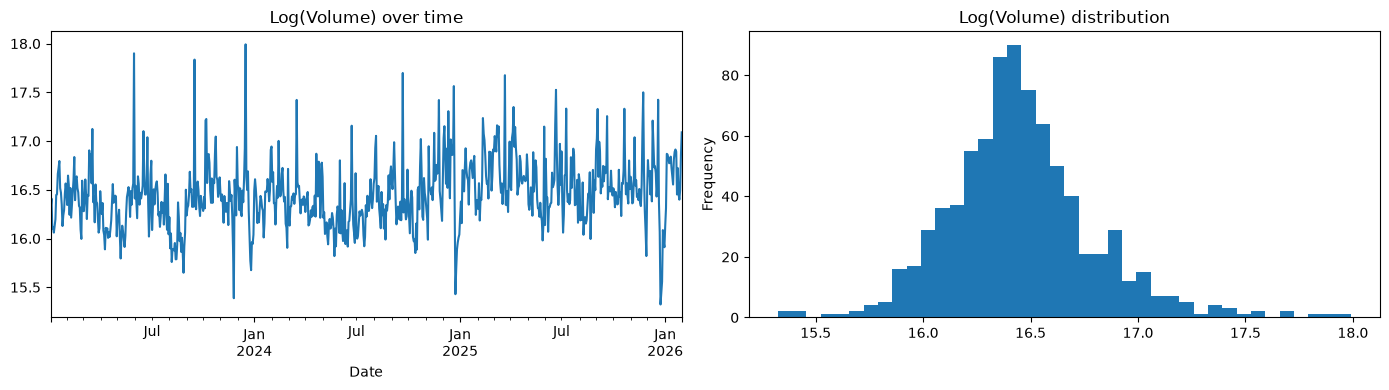

count    804.000000
mean      16.452522
std        0.335478
min       15.322982
25%       16.242466
50%       16.430919
75%       16.608816
max       17.992623
Name: log_Volume, dtype: float64
Skewness: 0.621931051516835


In [38]:
#Log Transformation + Recheck for distribution and skewness of the data
ts['log_Volume'] = np.log(ts['Volume'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ts['log_Volume'].plot(ax=axes[0], title='Log(Volume) over time')
ts['log_Volume'].plot(kind='hist', bins=40, ax=axes[1], title='Log(Volume) distribution')
plt.tight_layout()
plt.show()

print(ts['log_Volume'].describe())
print('Skewness:', ts['log_Volume'].skew())

In [39]:
#ADF Test for Stationarity
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'--- {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Stationary' if result[1] < 0.05 else 'Non-stationary')
    print()

adf_test(ts['Volume'], 'Volume (raw)')
adf_test(ts['log_Volume'], 'log(Volume)')

--- Volume (raw) ---
ADF Statistic: -8.5327
p-value: 0.0000
Stationary

--- log(Volume) ---
ADF Statistic: -7.7139
p-value: 0.0000
Stationary



In [40]:
#Fit AutoARIMA Model
from pmdarima import auto_arima

stationary_series = ts['log_Volume'].dropna()
adf_stat, p_value, *_ = adfuller(stationary_series)
print(f'ADF p-value for log(Volume): {p_value:.4f}')

if p_value < 0.05:
    series_for_model = stationary_series
    print('Series appears stationary; fitting AutoARIMA on the log-level series.')
else:
    series_for_model = stationary_series.diff().dropna()
    print('Series is not stationary; fitting AutoARIMA on the first-differenced series.')

model = auto_arima(
    series_for_model,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=False
)

print(model.summary())


ADF p-value for log(Volume): 0.0000
Series appears stationary; fitting AutoARIMA on the log-level series.
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  804
Model:               SARIMAX(1, 1, 2)   Log Likelihood                -115.469
Date:                Mon, 13 Jul 2026   AIC                            238.937
Time:                        23:34:44   BIC                            257.691
Sample:                    01-03-2023   HQIC                           246.140
                         - 01-30-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6550      0.057     11.450      0.000       0.543       0.767
ma.L1         -1.1985    

In [41]:
# Train/test split - use the last 20 observations for a more stable evaluation
forecast_horizon = 20
train_size = len(ts) - forecast_horizon
train = ts['log_Volume'].iloc[:train_size]
test = ts['log_Volume'].iloc[train_size:]

print(f'Train: {len(train)} obs, Test: {len(test)} obs')

Train: 784 obs, Test: 20 obs


In [42]:
# Refit ARIMA on train only, using the order auto_arima found (1,1,2)
arima_model = ARIMA(train, order=(1,1,2))
arima_fitted = arima_model.fit()

forecast_log = arima_fitted.forecast(steps=forecast_horizon)

# Convert back to actual Volume scale for interpretability
forecast_volume = np.exp(forecast_log)
actual_volume = np.exp(test)

c:\Users\TUF GAMING\Desktop\Forecasting Assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\TUF GAMING\Desktop\Forecasting Assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
c:\Users\TUF GAMING\Desktop\Forecasting Assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


In [43]:
# Naive benchmark: tomorrow's volume = today's volume (last known value repeated)
naive_forecast = np.full(len(test), np.exp(train.iloc[-1]))


def evaluate(actual, predicted, name):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    actual_safe = np.where(actual == 0, 1e-8, actual)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual_safe - predicted) / actual_safe)) * 100
    smape = np.mean(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted))) * 100

    print(f'{name}: MAE={mae:,.0f}, RMSE={rmse:,.0f}, MAPE={mape:.2f}%, sMAPE={smape:.2f}%')


evaluate(actual_volume, naive_forecast, 'Naive baseline')
evaluate(actual_volume, forecast_volume, 'ARIMA(1,1,2)')

mae_arima = mean_absolute_error(actual_volume, forecast_volume)
mae_naive = mean_absolute_error(actual_volume, naive_forecast)
print(f'ARIMA MAE improvement vs naive: {(1 - mae_arima / mae_naive) * 100:.2f}%')

Naive baseline: MAE=6,814,706, RMSE=7,571,594, MAPE=33.81%, sMAPE=41.98%
ARIMA(1,1,2): MAE=4,970,502, RMSE=5,867,388, MAPE=24.05%, sMAPE=28.48%
ARIMA MAE improvement vs naive: 27.06%


c:\Users\TUF GAMING\Desktop\Forecasting Assignment\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


Model comparison on 20-day holdout:
Naive baseline: MAE=6,814,706, RMSE=7,571,594, MAPE=33.81%
ARIMA(1,1,2): MAE=4,970,502, RMSE=5,867,388, MAPE=24.05%
Exponential Smoothing: MAE=8,950,134, RMSE=9,538,395, MAPE=45.45%
Random Forest: MAE=4,754,345, RMSE=6,221,178, MAPE=24.08%
Linear Regression: MAE=5,050,216, RMSE=6,332,130, MAPE=25.50%
XGBoost: MAE=4,852,727, RMSE=6,232,498, MAPE=24.16%
Best by MAE: Random Forest


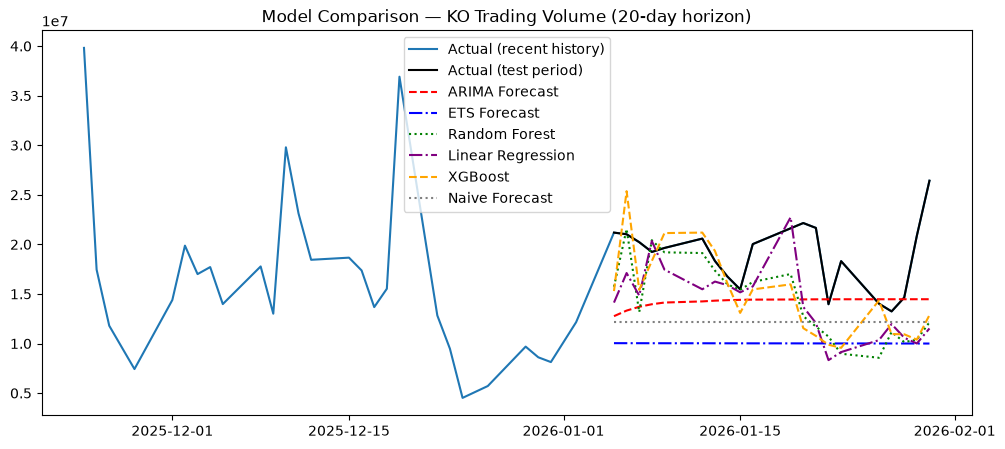

In [44]:
# Compare ARIMA, Exponential Smoothing, Naive, Random Forest, Linear Regression, and XGBoost on a longer holdout

# Fit Exponential Smoothing on the training log-volume series
ets_model = ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method='estimated')
ets_fit = ets_model.fit(optimized=True)
ets_forecast_log = ets_fit.forecast(steps=forecast_horizon)
ets_forecast_volume = np.exp(ets_forecast_log)

# Convert to plain numeric arrays for reliable metric calculation
actual_volume = np.exp(test).to_numpy(dtype=float)
forecast_volume_array = np.asarray(forecast_volume, dtype=float)
ets_forecast_volume_array = np.asarray(ets_forecast_volume, dtype=float)
naive_forecast_array = np.asarray(naive_forecast, dtype=float)

# Create richer lag and rolling-mean features from the log-volume series
series = ts['log_Volume'].dropna().to_numpy(dtype=float)
lag_values = [1, 2, 3, 5, 10]
rolling_windows = [3, 5, 10]

rows = []
labels = []
for i in range(len(series) - max(lag_values) - forecast_horizon):
    row = []
    for lag in lag_values:
        row.append(series[i + lag - 1])
    for window in rolling_windows:
        window_values = series[max(0, i - window + 1):i]
        row.append(np.mean(window_values) if len(window_values) > 0 else series[i])
    row.append(series[i])
    rows.append(row)
    labels.append(series[i + max(lag_values)])

X = np.array(rows, dtype=float)
y = np.array(labels, dtype=float)

# Use the last 20 rows as the holdout for the supervised models
train_X, test_X = X[:-forecast_horizon], X[-forecast_horizon:]
train_y, test_y = y[:-forecast_horizon], y[-forecast_horizon:]

# Fit baseline regression models with richer features
rf_model = RandomForestRegressor(n_estimators=400, random_state=42, max_depth=10)
rf_model.fit(train_X, train_y)
rf_pred_log = rf_model.predict(test_X)
rf_pred_volume = np.exp(rf_pred_log)

lr_model = LinearRegression()
lr_model.fit(train_X, train_y)
lr_pred_log = lr_model.predict(test_X)
lr_pred_volume = np.exp(lr_pred_log)

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42)
xgb_model.fit(train_X, train_y)
xgb_pred_log = xgb_model.predict(test_X)
xgb_pred_volume = np.exp(xgb_pred_log)

# Evaluate all models
results = []
for name, preds in [
    ('Naive baseline', naive_forecast_array),
    ('ARIMA(1,1,2)', forecast_volume_array),
    ('Exponential Smoothing', ets_forecast_volume_array),
    ('Random Forest', rf_pred_volume),
    ('Linear Regression', lr_pred_volume),
    ('XGBoost', xgb_pred_volume),
]:
    mae = mean_absolute_error(actual_volume, preds)
    rmse = np.sqrt(mean_squared_error(actual_volume, preds))
    mape = np.mean(np.abs((actual_volume - preds) / actual_volume)) * 100
    results.append((name, mae, rmse, mape))

print('Model comparison on 20-day holdout:')
for name, mae, rmse, mape in results:
    print(f'{name}: MAE={mae:,.0f}, RMSE={rmse:,.0f}, MAPE={mape:.2f}%')

best_model = min(results, key=lambda x: x[1])
print(f'Best by MAE: {best_model[0]}')

# Visualize forecast vs actual
plt.figure(figsize=(12,5))
plt.plot(ts.index[-(forecast_horizon + 30):], np.exp(ts['log_Volume'].iloc[-(forecast_horizon + 30):]), label='Actual (recent history)')
plt.plot(test.index, actual_volume, label='Actual (test period)', color='black')
plt.plot(test.index, forecast_volume_array, label='ARIMA Forecast', color='red', linestyle='--')
plt.plot(test.index, ets_forecast_volume_array, label='ETS Forecast', color='blue', linestyle='-.')
plt.plot(test.index, rf_pred_volume, label='Random Forest', color='green', linestyle=':')
plt.plot(test.index, lr_pred_volume, label='Linear Regression', color='purple', linestyle='-.')
plt.plot(test.index, xgb_pred_volume, label='XGBoost', color='orange', linestyle='--')
plt.plot(test.index, naive_forecast_array, label='Naive Forecast', color='gray', linestyle=':')
plt.legend()
plt.title('Model Comparison — KO Trading Volume (20-day horizon)')
plt.show()


In [45]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
n_sims = 1000
n_days = forecast_horizon  # 20

# Simulate future paths directly from the fitted ARIMA model
# This respects the AR/MA structure (mean-reversion), unlike a naive random walk
sim_results = arima_fitted.simulate(
    nsimulations=n_days,
    repetitions=n_sims,
    anchor='end'
)

# sim_results shape: (n_days, n_sims) in log-scale — convert back to actual Volume
sim_paths = np.exp(sim_results.values.reshape(n_days, n_sims))

sim_median = np.median(sim_paths, axis=1)
sim_p5 = np.percentile(sim_paths, 5, axis=1)
sim_p95 = np.percentile(sim_paths, 95, axis=1)

print(f"Median forecast at day {n_days}: {sim_median[-1]:,.0f}")
print(f"5th percentile (downside risk): {sim_p5[-1]:,.0f}")
print(f"95th percentile (upside scenario): {sim_p95[-1]:,.0f}")

Median forecast at day 20: 14,478,097
5th percentile (downside risk): 8,323,777
95th percentile (upside scenario): 24,717,294


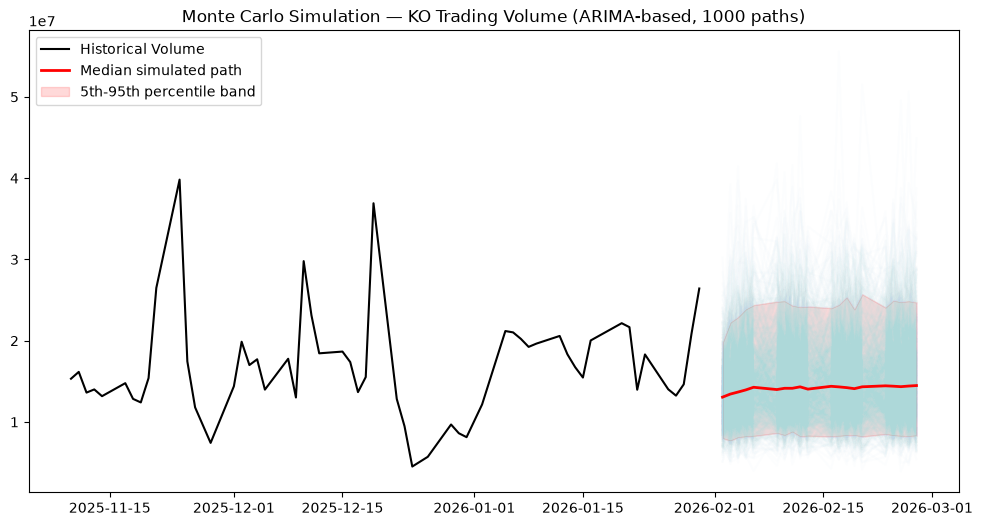

In [47]:
# Plot — same as before
future_dates = pd.bdate_range(start=ts.index[-1] + pd.Timedelta(days=1), periods=n_days)

plt.figure(figsize=(12,6))
plt.plot(ts.index[-60:], ts['Volume'].iloc[-60:], label='Historical Volume', color='black')
plt.plot(future_dates, sim_paths, color='lightblue', alpha=0.03)
plt.plot(future_dates, sim_median, color='red', label='Median simulated path', linewidth=2)
plt.fill_between(future_dates, sim_p5, sim_p95, color='red', alpha=0.15, label='5th-95th percentile band')
plt.legend()
plt.title('Monte Carlo Simulation — KO Trading Volume (ARIMA-based, 1000 paths)')
plt.show()

In [48]:
print(f"Day 1 — Median: {sim_median[0]:,.0f} | 5th-95th: {sim_p5[0]:,.0f} to {sim_p95[0]:,.0f}")
print(f"Day {n_days} — Median: {sim_median[-1]:,.0f} | 5th-95th: {sim_p5[-1]:,.0f} to {sim_p95[-1]:,.0f}")
print(f"\nAverage historical volume (last 90 days): {ts['Volume'].iloc[-90:].mean():,.0f}")
print(f"Probability of exceeding 30M on any given day (based on simulation): {(sim_paths > 30_000_000).mean() * 100:.1f}%")

Day 1 — Median: 13,054,811 | 5th-95th: 7,986,759 to 19,778,497
Day 20 — Median: 14,478,097 | 5th-95th: 8,323,777 to 24,717,294

Average historical volume (last 90 days): 16,267,990
Probability of exceeding 30M on any given day (based on simulation): 1.1%
